In [783]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [784]:
data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
data.data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [785]:
X = data.data
X = X / 255.0
y = data.target

In [786]:
def display_image(index, X, y):
    print(f'\nLabel: {y[index]}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.show()


Label: 4



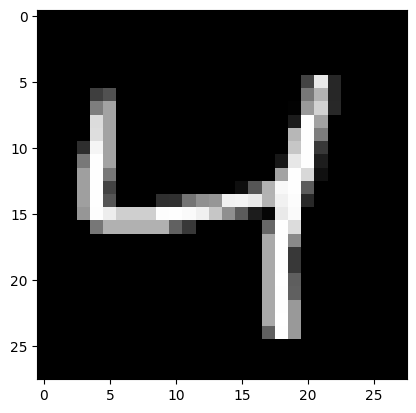

In [787]:
display_image(2, X, y)

In [788]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self, output_gradient, learning_rate, batch_size):
        pass

    def adam_update(self, learning_rate, beta1, beta2, eps, t):
        pass

In [824]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size
        self.weights = np.random.randn(self.output_size, self.input_size) * np.sqrt(2 / input_size)
        self.biases = np.zeros((self.output_size, 1))

        # Adam state
        self.m_W = np.zeros_like(self.weights)
        self.v_W = np.zeros_like(self.weights)
        self.m_b = np.zeros_like(self.biases)
        self.v_b = np.zeros_like(self.biases)

    def forward(self, input):
        self.input = input
        return self.weights @ self.input + self.biases
        

    def backward(self, output_gradient, learning_rate):
        batch_size = output_gradient.shape[1]

        self.dW = output_gradient @ self.input.T / batch_size
        self.dB = np.sum(output_gradient, axis=1, keepdims=True) / batch_size
        dX = self.weights.T @ output_gradient

        return dX

    def adam_update(self, learning_rate, beta1, beta2, eps, t):
        
        # Update moments for weights
        
        self.m_W = beta1 * self.m_W + (1 - beta1) * self.dW
        self.v_W = beta2 * self.v_W + (1 - beta2) * (self.dW ** 2)

        # Bias correction
        
        m_W_hat = self.m_W / (1 - beta1**t)
        v_W_hat = self.v_W / (1 - beta2**t)

        # Update weights

        self.weights -= learning_rate * m_W_hat / (np.sqrt(v_W_hat) + eps)
        
        # Update Biases
        
        self.m_b = beta1 * self.m_b + (1 - beta1) * self.dB
        self.v_b = beta2 * self.v_b + (1 - beta2) * (self.dB ** 2)

        m_b_hat = self.m_b / (1 - beta1**t)
        v_b_hat = self.v_b / (1 - beta2**t)

        self.biases -= learning_rate * m_b_hat / (np.sqrt(v_b_hat) + eps)
        

In [821]:
class Activation(Layer):
    def __init__(self, activation_function, activation_prime):
        self.activation_function = activation_function
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation_function(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [791]:
class Tanh(Activation):
    def __init__(self):
        tanh = lambda x: np.tanh(x)
        tanh_prime = lambda x: 1 - np.tanh(x)**2
        super().__init__(tanh, tanh_prime)

In [792]:
class ReLU(Activation):
    def __init__(self):
        relu = lambda x: np.fmax(0, x)
        relu_prime = lambda x: (x > 0).astype(float)
        super().__init__(relu, relu_prime)

In [793]:
class Softmax(Activation):
    def __init__(self):
        softmax_prime = lambda x: 1
        super().__init__(self.softmax, softmax_prime)

    def softmax(self, x):
        x = x - np.max(x, axis=0, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=0, keepdims=True)

In [794]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

def cross_entropy_prime(y_true, y_pred):
    return y_pred - y_true
    

In [795]:
def one_hot_encode(data):
    one_hot = []
    for d in data:
        one_hot.append(np.zeros((10, 1)))
        one_hot[-1][int(d)] = 1
    return np.array(one_hot)

In [796]:
X = X.reshape(70000, 784, 1)
y_one_hot = one_hot_encode(y)

In [797]:
X.shape, y_one_hot.shape

((70000, 784, 1), (70000, 10, 1))

In [836]:
class NeuralNetwork:
    def __init__(self, network):
        self.network = network

    def predict(self, data):
        output = data
        for layer in self.network:
            output = layer.forward(output)
        return output

    def score(self, X, y):
        X = X.squeeze(-1).T
        y = y.squeeze(-1).T
        preds = np.argmax(self.predict(X), axis=0)
        labels = np.argmax(y, axis=0)
        return np.sum(preds == labels) / y.shape[1]

    def train(self, X, y, learning_rate=0.1, epoch=16, batch_size=100):
        self.t = 0
        for e in range(epoch):
            perm = np.random.permutation(len(X))
            X = X[perm]
            y = y[perm]
            error = 0
            correct = 0
            for i in range(0, len(X), batch_size):
                X_batch = X[i:i + batch_size].squeeze(-1).T
                y_batch = y[i:i + batch_size].squeeze(-1).T
                output = self.predict(X_batch)
                loss = cross_entropy(y_batch, output)
                error += loss
                preds = np.argmax(output, axis=0)
                labels = np.argmax(y_batch, axis=0)
                correct += np.sum(preds == labels)
                self.t += 1
                gradient = cross_entropy_prime(y_batch, output)
                for layer in reversed(self.network):
                    gradient = layer.backward(gradient, learning_rate)
                    layer.adam_update(
                        learning_rate=learning_rate,
                        beta1=0.9,
                        beta2=0.999,
                        eps=1e-8,
                        t=self.t
                    )
            print(f"Epoch: {e + 1}/{epoch} | Cross Entropy Loss: {error / y.shape[0]} | Accuracy: {correct / y.shape[0]}")
        print(f"Model Accuracy on Training Data: {self.score(X, y)}")

In [837]:
NN = NeuralNetwork([
    Dense(784, 64),
    ReLU(),
    Dense(64, 32),
    ReLU(),
    Dense(32, 16),
    Tanh(),
    Dense(16, 10),
    Softmax(),
])

In [838]:
X_train = X[:50000]
X_test = X[50000:]
y_train = y_one_hot[:50000]
y_test_norm = y[50000:]
y_test = y_one_hot[50000:]

In [839]:
NN.train(X_train, y_train, learning_rate=.001, epoch=16, batch_size=100)

Epoch: 1/16 | Cross Entropy Loss: 0.49695061324230655 | Accuracy: 0.87366
Epoch: 2/16 | Cross Entropy Loss: 0.18437740070481903 | Accuracy: 0.94922
Epoch: 3/16 | Cross Entropy Loss: 0.13304376181147906 | Accuracy: 0.96202
Epoch: 4/16 | Cross Entropy Loss: 0.10343128635659679 | Accuracy: 0.96996
Epoch: 5/16 | Cross Entropy Loss: 0.08644159560649671 | Accuracy: 0.97524
Epoch: 6/16 | Cross Entropy Loss: 0.07342781058435335 | Accuracy: 0.97846
Epoch: 7/16 | Cross Entropy Loss: 0.06084554296150637 | Accuracy: 0.98194
Epoch: 8/16 | Cross Entropy Loss: 0.051318221658567316 | Accuracy: 0.985
Epoch: 9/16 | Cross Entropy Loss: 0.047081689349958725 | Accuracy: 0.98662
Epoch: 10/16 | Cross Entropy Loss: 0.04015812105761169 | Accuracy: 0.98796
Epoch: 11/16 | Cross Entropy Loss: 0.0342646306914467 | Accuracy: 0.98998
Epoch: 12/16 | Cross Entropy Loss: 0.030531753888524516 | Accuracy: 0.99166
Epoch: 13/16 | Cross Entropy Loss: 0.029912289755779347 | Accuracy: 0.99138
Epoch: 14/16 | Cross Entropy Loss

In [842]:
NN.score(X_test, y_test)

0.97295

In [830]:
def display_image_prediction(index, X, y, network):
    output = network.predict(X[index])
    print(f'\nLabel: {y[index]} | Predicted: {np.argmax(output)}\n')
    image = X[index].reshape(28, 28)
    plt.imshow(image)
    plt.show()


Label: 3 | Predicted: 3



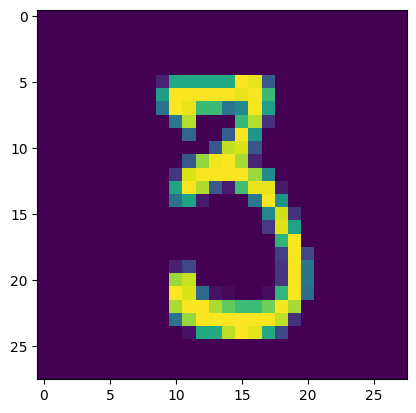

In [831]:
display_image_prediction(43, X_test, y_test_norm, NN)

In [832]:
def show_incorrect(X, y, network):
    X_sq = X.squeeze(-1).T
    y_sq = y.squeeze(-1).T
    
    output = network.predict(X_sq)
    preds = np.argmax(output, axis=0)
    labels = np.argmax(y_sq, axis=0)
    
    incorrect = np.where(preds != labels)
    for i in incorrect[0]:
        display_image_prediction(i, X, np.argmax(y, axis=1), network)
    return incorrect


Label: [4] | Predicted: 9



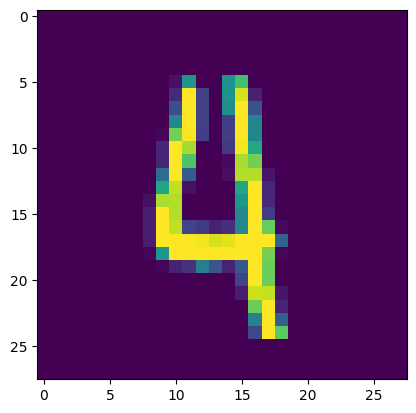


Label: [4] | Predicted: 6



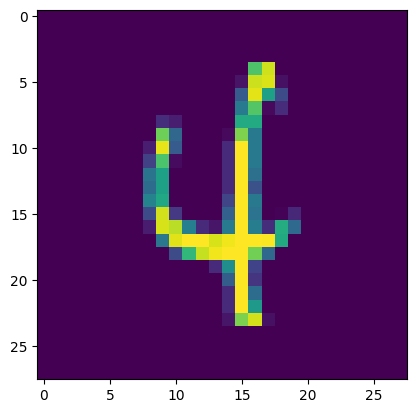


Label: [1] | Predicted: 7



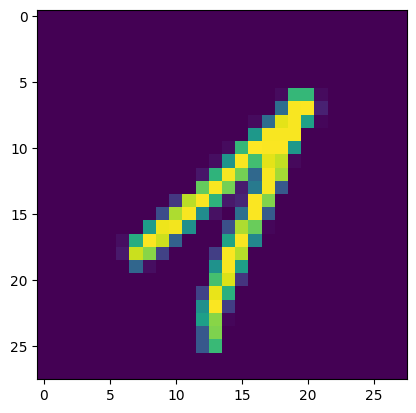


Label: [2] | Predicted: 1



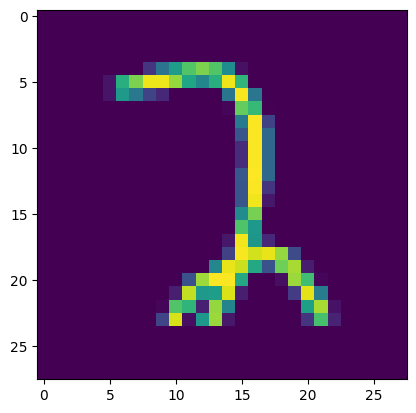


Label: [3] | Predicted: 8



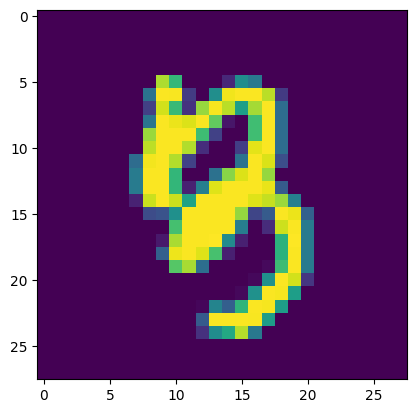


Label: [5] | Predicted: 8



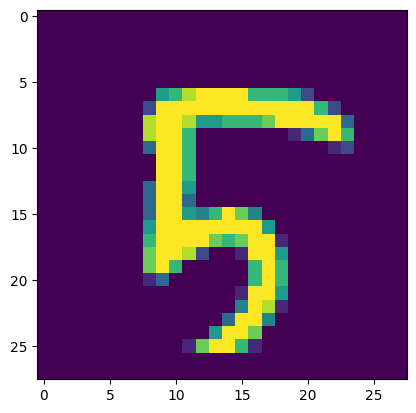


Label: [0] | Predicted: 6



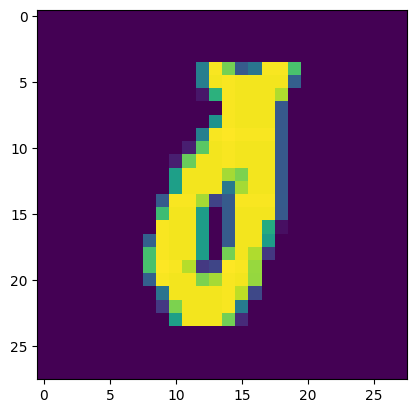


Label: [9] | Predicted: 0



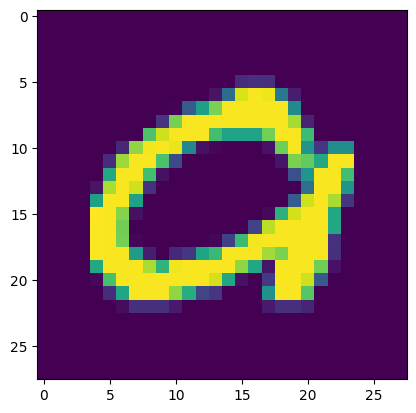


Label: [3] | Predicted: 8



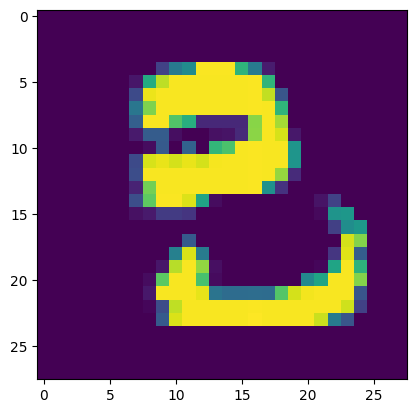


Label: [5] | Predicted: 9



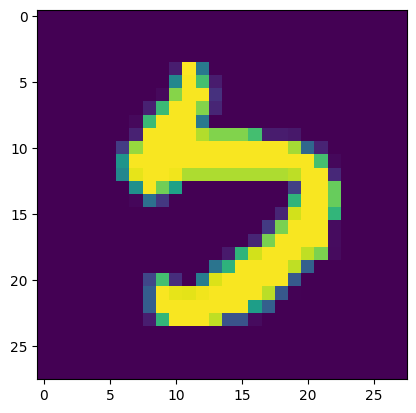


Label: [5] | Predicted: 3



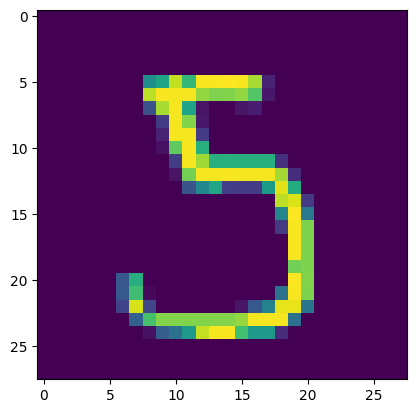


Label: [9] | Predicted: 7



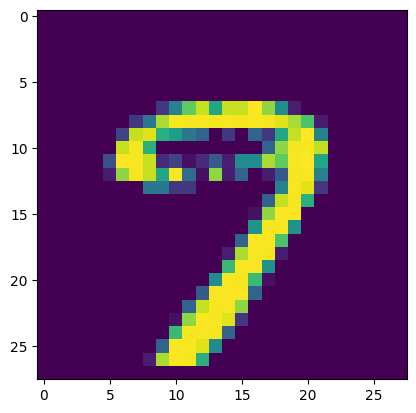


Label: [3] | Predicted: 2



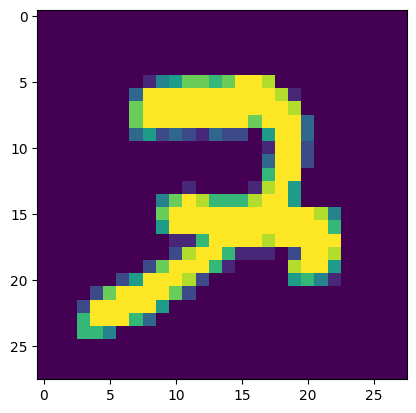


Label: [6] | Predicted: 1



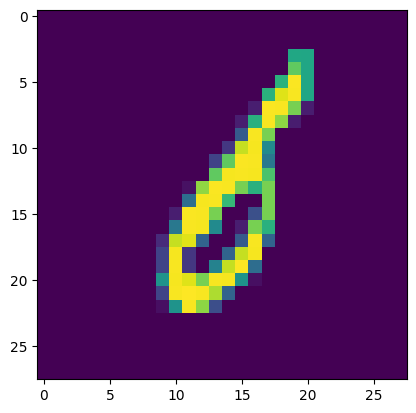


Label: [9] | Predicted: 7



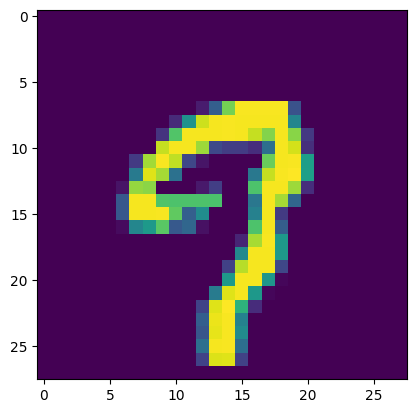


Label: [8] | Predicted: 7



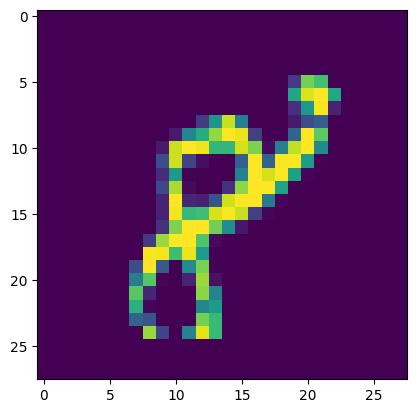


Label: [9] | Predicted: 3



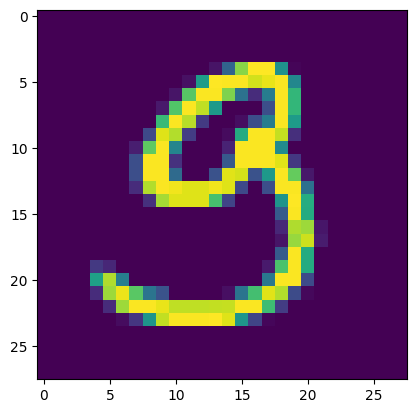


Label: [3] | Predicted: 5



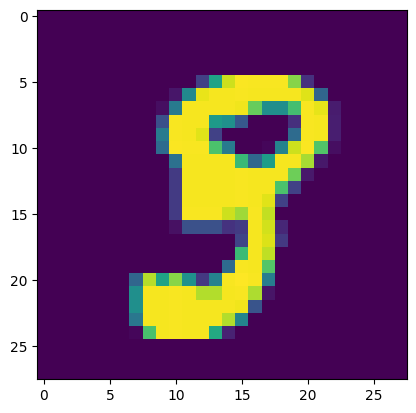


Label: [7] | Predicted: 2



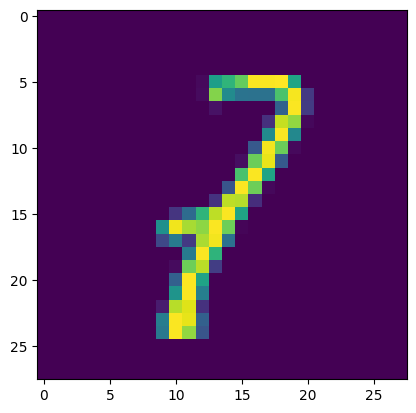


Label: [2] | Predicted: 8



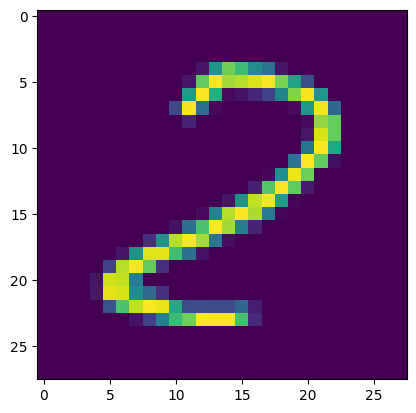


Label: [9] | Predicted: 7



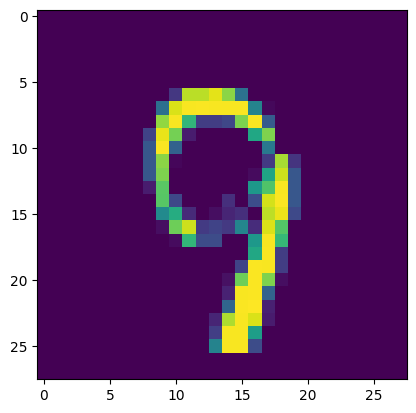


Label: [3] | Predicted: 8



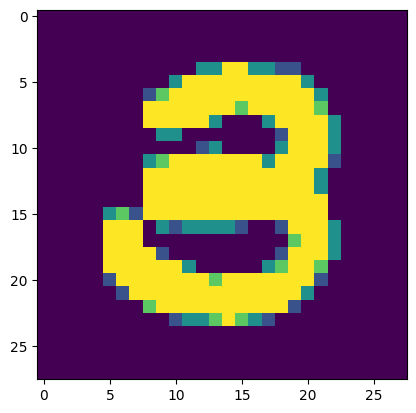


Label: [8] | Predicted: 3



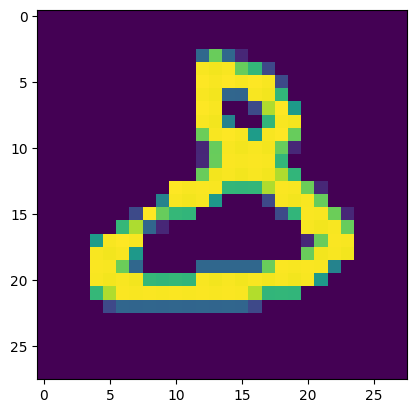


Label: [9] | Predicted: 8



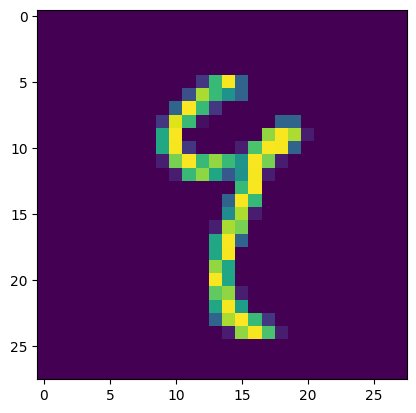


Label: [9] | Predicted: 7



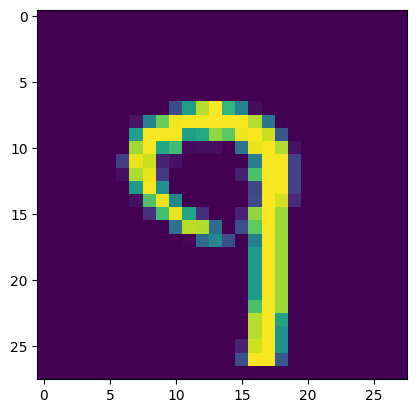


Label: [1] | Predicted: 2



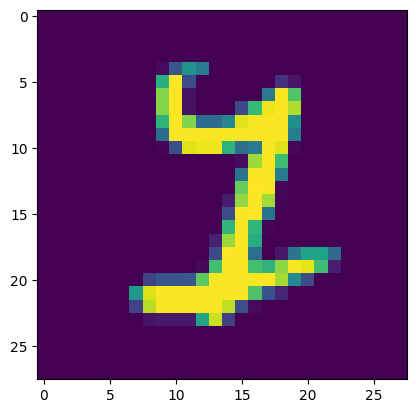


Label: [5] | Predicted: 6



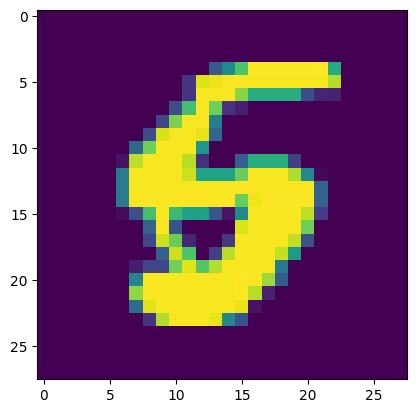


Label: [1] | Predicted: 2



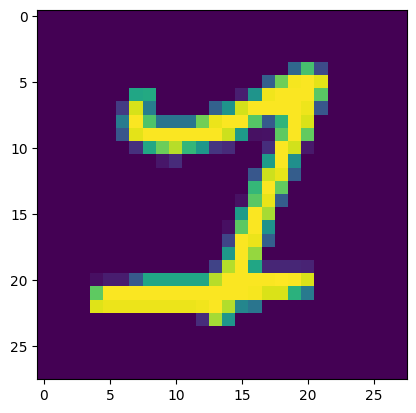


Label: [5] | Predicted: 3



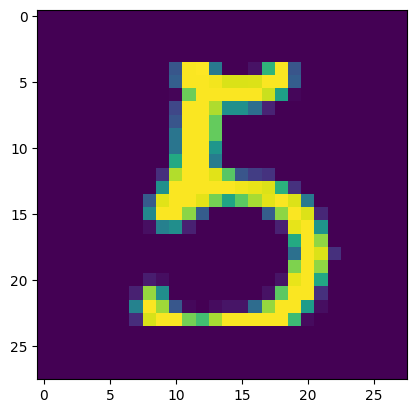


Label: [8] | Predicted: 3



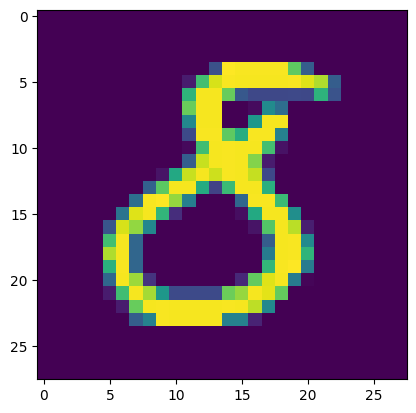


Label: [8] | Predicted: 0



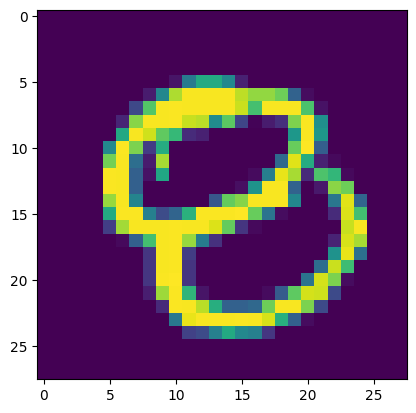


Label: [4] | Predicted: 7



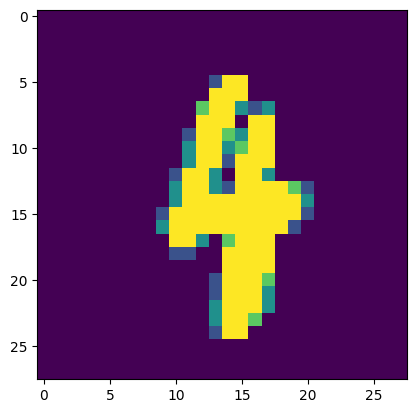


Label: [4] | Predicted: 1



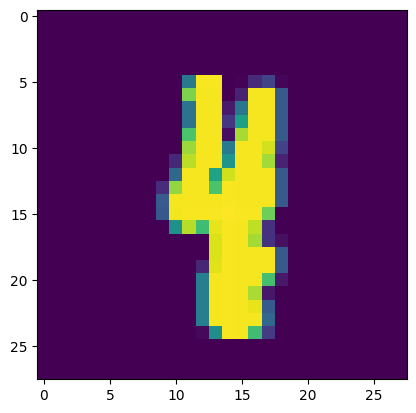


Label: [5] | Predicted: 3



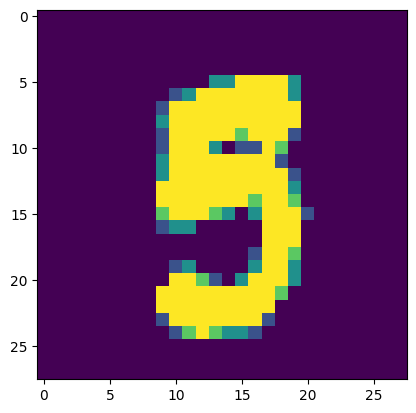


Label: [9] | Predicted: 3



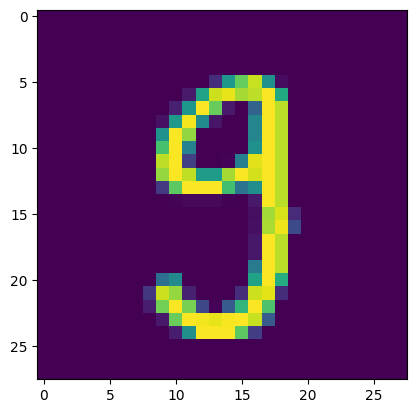


Label: [3] | Predicted: 5



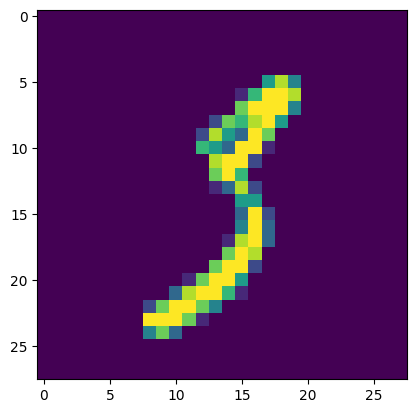


Label: [9] | Predicted: 4



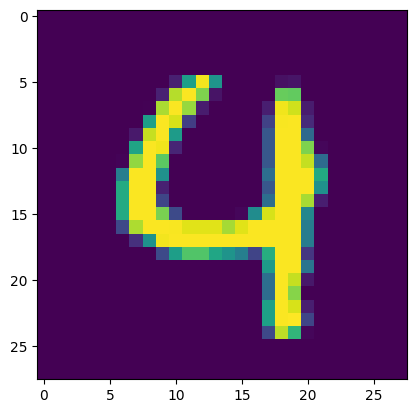


Label: [9] | Predicted: 4



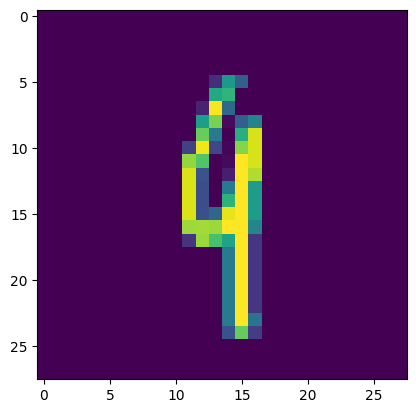


Label: [5] | Predicted: 8



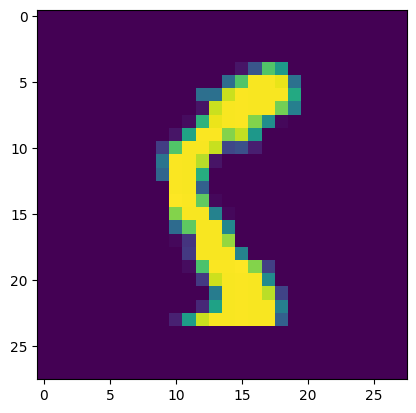


Label: [7] | Predicted: 1



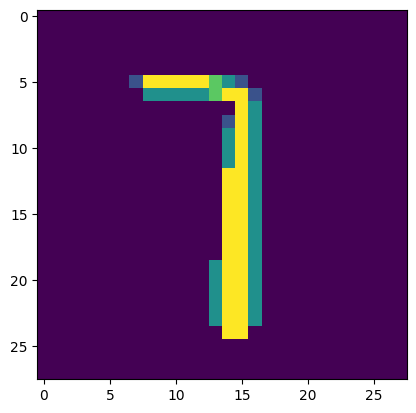


Label: [4] | Predicted: 6



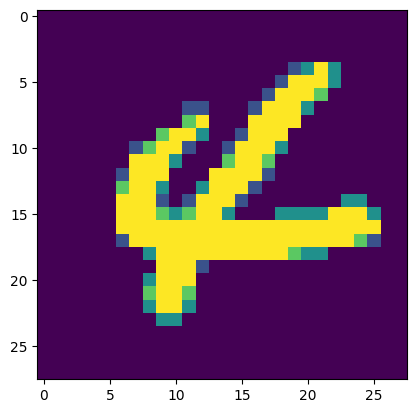


Label: [9] | Predicted: 4



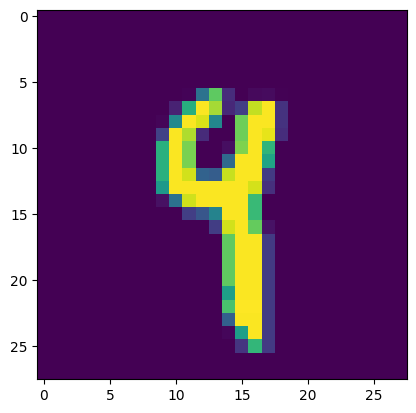


Label: [0] | Predicted: 2



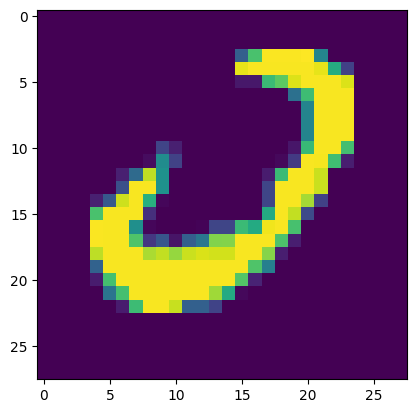


Label: [0] | Predicted: 9



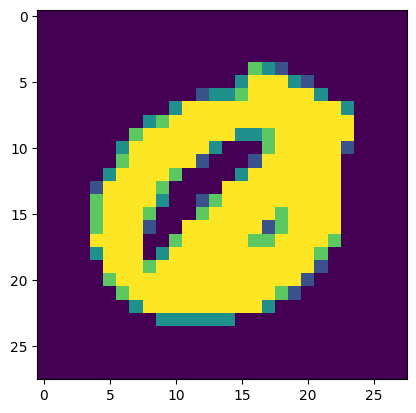


Label: [6] | Predicted: 2



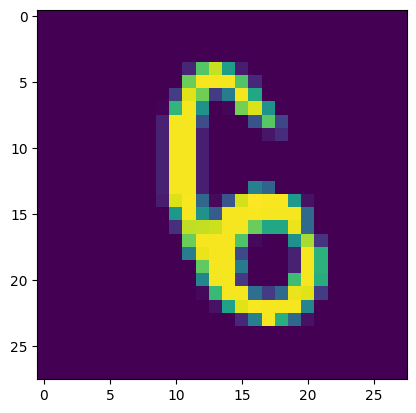


Label: [3] | Predicted: 7



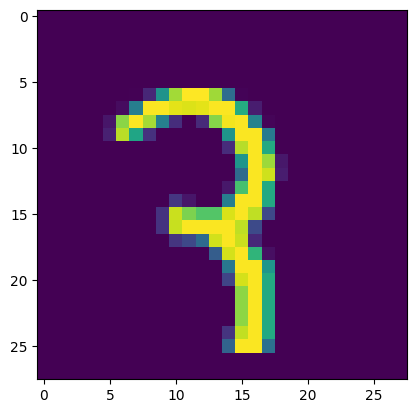


Label: [1] | Predicted: 3



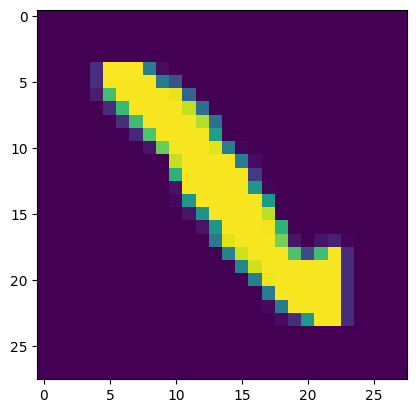


Label: [4] | Predicted: 8



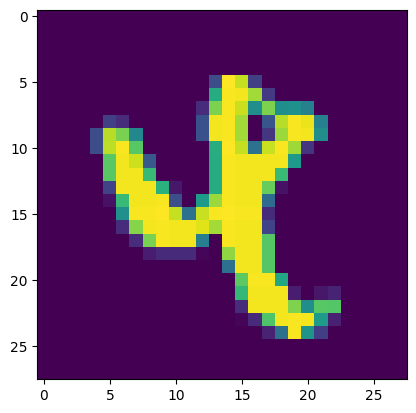


Label: [4] | Predicted: 9



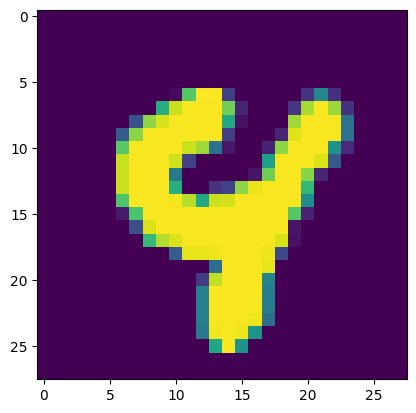


Label: [9] | Predicted: 4



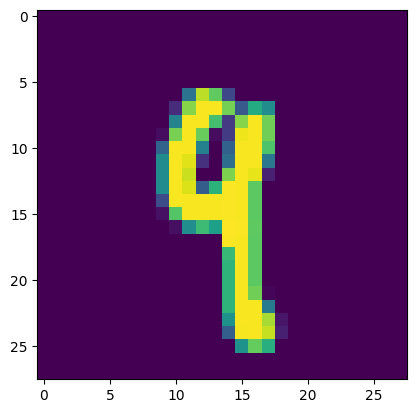


Label: [2] | Predicted: 7



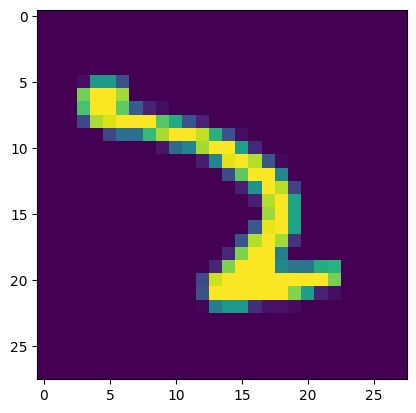


Label: [5] | Predicted: 7



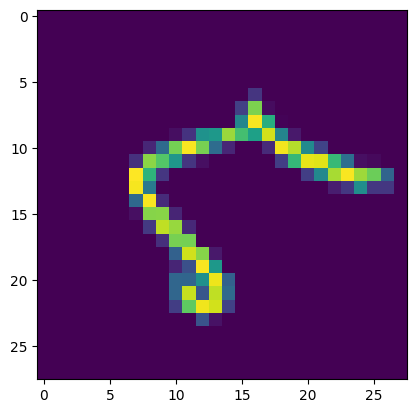


Label: [5] | Predicted: 2



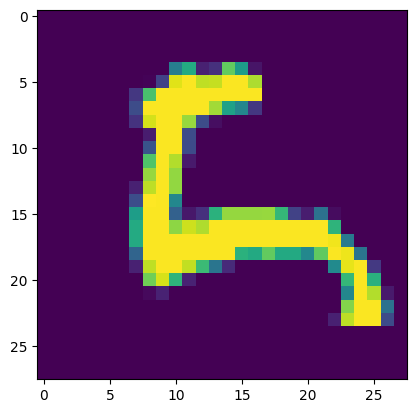


Label: [4] | Predicted: 9



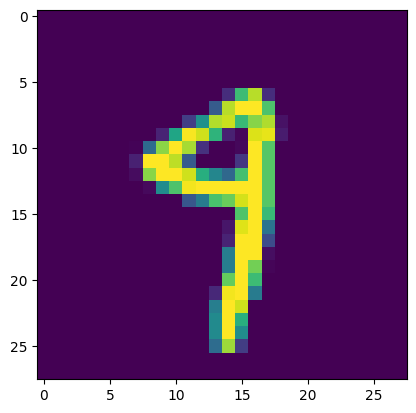


Label: [5] | Predicted: 6



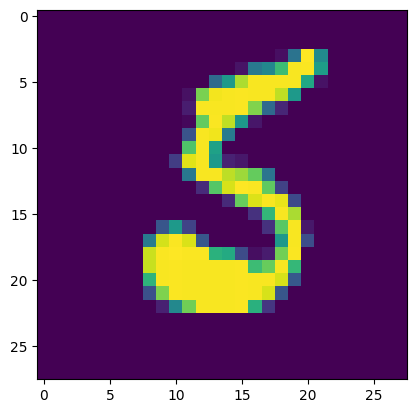


Label: [5] | Predicted: 3



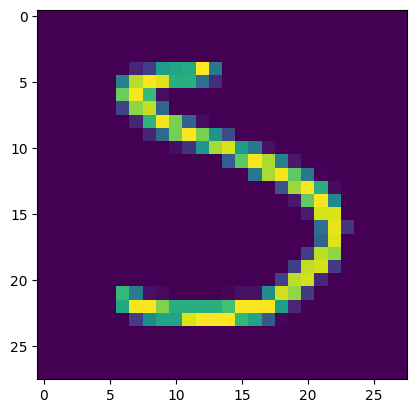


Label: [9] | Predicted: 4



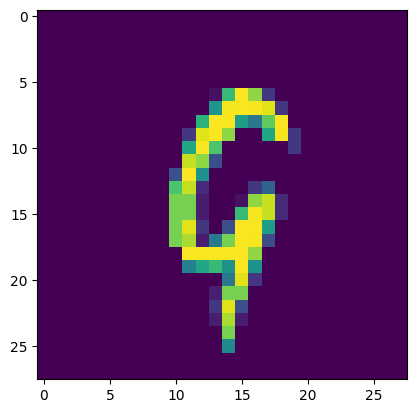


Label: [5] | Predicted: 9



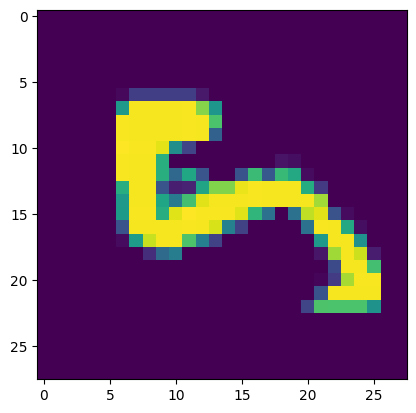


Label: [5] | Predicted: 0



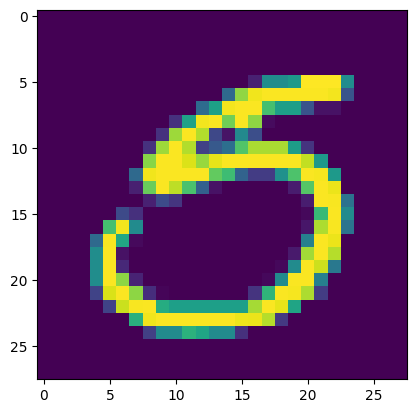


Label: [3] | Predicted: 5



KeyboardInterrupt: 

In [833]:
show_incorrect(X_test, y_test, NN)